                            Seq2Seq

In [1]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Get:1 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:2 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1498 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]m
Get:6 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]
Get:8 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3491 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1986 kB]33m
Get:11 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [34.2 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:13 http://archive.ubuntu.com/ubuntu

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


데이터 전처리

In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [5]:
dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


In [6]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [7]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


In [8]:
df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .


In [9]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [10]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [11]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

In [12]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,v yase .
4,hi .,hola .
...,...,...
29995,we ll go after we eat .,iremos despu s de comer .
29996,we ll live like kings .,viviremos como reyes .
29997,we ll lose everything .,lo perderemos todo .
29998,we ll meet right here .,nos encontraremos aqu mismo .


In [13]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


In [14]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 27, 7, 39, 324, 9, 2]

In [15]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

In [16]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [17]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


모델설계

In [19]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [20]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [21]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [22]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [24]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [25]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


In [26]:
Encoder

__main__.Encoder

In [27]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)
        # hidden  : (1, batch_size, hidden_dim)  # num_layers * num_directions, batch, hidden_dim

        return outputs, hidden, cell

In [28]:
Decoder

__main__.Decoder

In [29]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, cell, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)

        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

                            훈련하기

In [30]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


train_step 구현하기

In [31]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


훈련 시작하기

In [32]:
# %%time

# EPOCHS = 10

# for epoch in range(EPOCHS):
#     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

실습하기

In [33]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [ ]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:38<00:00,  9.78it/s, loss=2.32]


Epoch 1/20, Train Loss: 3.0561, Validation Loss: 2.1154


Epoch 2: 100%|██████████| 375/375 [00:38<00:00,  9.77it/s, loss=1.43]


Epoch 2/20, Train Loss: 1.5268, Validation Loss: 1.6316


Epoch 3: 100%|██████████| 375/375 [00:38<00:00,  9.73it/s, loss=1.1]  


...

Epoch 17: 100%|██████████| 375/375 [00:38<00:00,  9.69it/s, loss=0.231] 


Epoch 17/20, Train Loss: 0.1937, Validation Loss: 1.8454


Epoch 18: 100%|██████████| 375/375 [00:38<00:00,  9.70it/s, loss=0.38]  


Epoch 18/20, Train Loss: 0.1920, Validation Loss: 1.8708


Epoch 19: 100%|██████████| 375/375 [00:38<00:00,  9.73it/s, loss=0.319] 


Attention map의 시각화

In [34]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [35]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [36]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['el', 'p', 'bl', 'ico', 'se', 'detuv', 'o', '.', '']


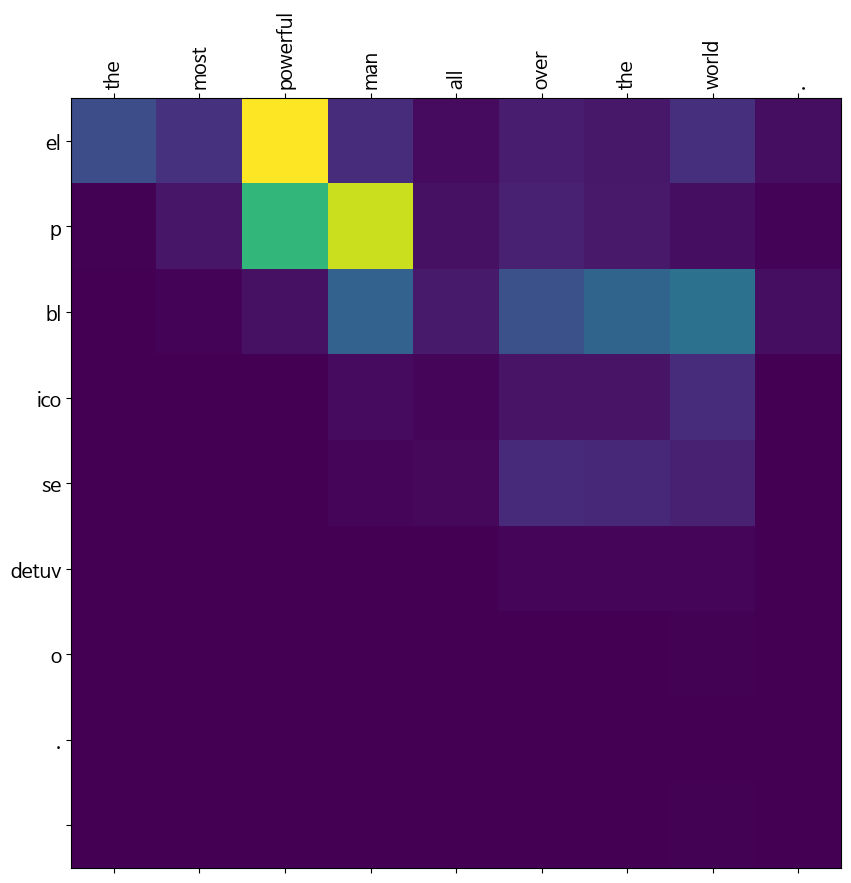

In [37]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['pued', 'o', 'ayudar', '?', '']


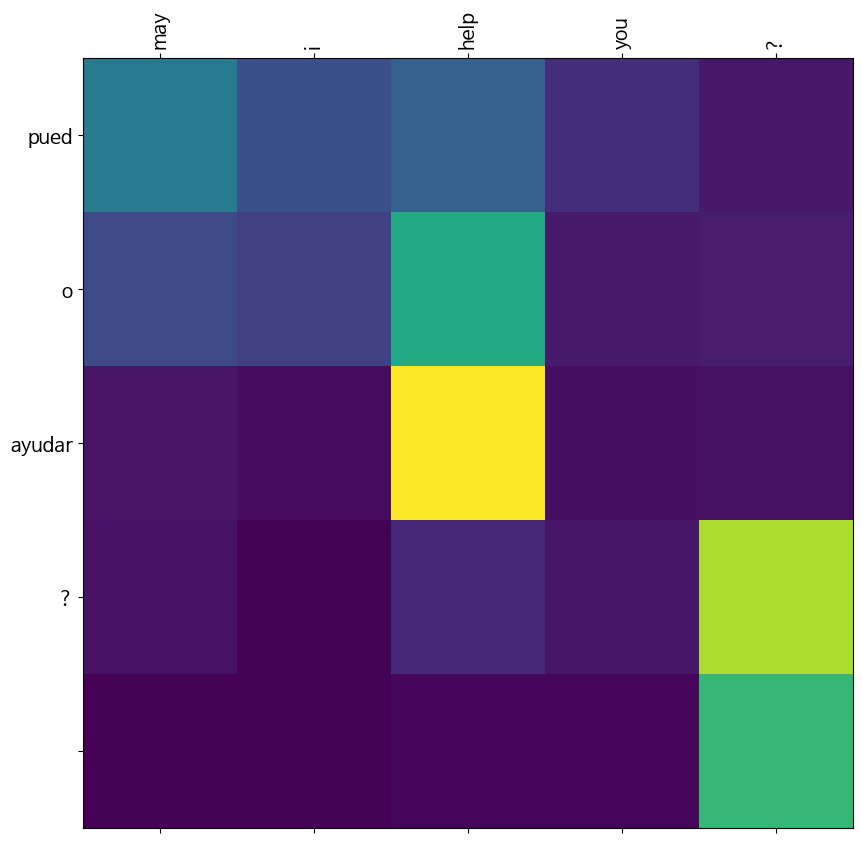

In [38]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

eval_step 예시 코드

In [39]:
# Define eval_step

def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")


# Training Process

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

슝~


Epoch 1: 100%|██████████| 375/375 [00:39<00:00,  9.61it/s, loss=0.333] 


Epoch 1/20, Train Loss: 0.1878, Validation Loss: 1.8850


Epoch 2: 100%|██████████| 375/375 [00:39<00:00,  9.60it/s, loss=0.162] 


Epoch 2/20, Train Loss: 0.1830, Validation Loss: 1.9034


...

Epoch 18/20, Train Loss: 0.1613, Validation Loss: 2.0026


Epoch 19: 100%|██████████| 375/375 [00:39<00:00,  9.58it/s, loss=0.216] 


Epoch 19/20, Train Loss: 0.1578, Validation Loss: 2.0084


Epoch 20: 100%|██████████| 375/375 [00:39<00:00,  9.52it/s, loss=0.186] 


Epoch 20/20, Train Loss: 0.1559, Validation Loss: 2.0182


                            한국어 번역기 만들기

데이터 다운로드

In [35]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


데이터정제

In [41]:
#cleand_corpus

In [36]:
# 데이터를 읽어오는 코드가 이전에 실행되어 있어야 합니다!
# 예시:
kor_corpus = ["안녕하세요.", "반갑습니다."] 
eng_corpus = ["Hello.", "Nice to meet you."]

# 이제 아래 코드가 정상 작동해야
combined_corpus = set(zip(kor_corpus, eng_corpus))
cleaned_corpus = list(combined_corpus)

In [37]:
# kor_corpus와 eng_corpus가 이미 리스트로 존재한다고 가정합니다.
# zip으로 묶어서 중복을 제거한 뒤 다시 풀어줍니다.
combined_corpus = set(zip(kor_corpus, eng_corpus))
cleaned_corpus = list(combined_corpus)

print(f"중복 제거 후 데이터 개수: {len(cleaned_corpus)}")

중복 제거 후 데이터 개수: 2


In [38]:
#한글 정규식 추가 및 preprocessing() 재정의

In [39]:
import re

def preprocessing(sentence, is_english=False):
    # 소문자 변환 및 양쪽 공백 제거
    sentence = sentence.lower().strip()
    
    # 문장 부호 양옆에 공백 추가
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 한글, 영문, 숫자, 지정된 문장 부호 제외하고 제거
    if is_english:
        sentence = re.sub(r"[^a-zA-Z?.!,¿]+", " ", sentence)
        # 타겟 언어인 영어에만 토큰 추가
        sentence = f"<start> {sentence} <end>"
    else:
        sentence = re.sub(r"[^가-힣?.!,¿]+", " ", sentence)

    return sentence.strip()

In [40]:
#토큰화 및 데이터 선별 (길이 40 이하)

In [41]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 41.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


In [42]:
!wget https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh
!bash mecab.sh

--2026-05-02 12:09:28--  https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5323 (5.2K) [text/plain]
Saving to: ‘mecab.sh.3’

mecab.sh.3          100%[===================>]   5.20K  --.-KB/s    in 0s      

2026-05-02 12:09:29 (46.4 MB/s) - ‘mecab.sh.3’ saved [5323/5323]

Installing automake (A dependency for mecab-ko)
Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The

In [43]:
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 1.9 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 2.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]


In [44]:
from mecab import MeCab  # 대문자 C 주의!
mecab = MeCab()

# 테스트
print(mecab.morphs("얄공님, 이제 에러 끝입니다!"))

['얄', '공', '님', ',', '이제', '에러', '끝', '입니다', '!']


In [45]:
!pip install python-mecab-ko

In [46]:
from mecab import MeCab  # konlpy.tag 대신 이걸 씁니다.
mecab = MeCab()

# 테스트: 에러 없이 출력되면 성공!
print(mecab.morphs("얄공님, 이제 에러 끝입니다!"))

def tokenize(corpus, is_english=False):
    kor_res, eng_res = [], []
    
    for kor, eng in corpus:
        # 이전에 정의한 preprocessing 함수를 사용합니다.
        pre_kor = preprocessing(kor, is_english=False)
        pre_eng = preprocessing(eng, is_english=True)
        
        # mecab.morphs로 토큰화
        token_kor = mecab.morphs(pre_kor)
        token_eng = pre_eng.split()
        
        # 얄공님의 요청: 토큰 길이 40 이하만 선별
        if len(token_kor) <= 40 and len(token_eng) <= 40:
            kor_res.append(token_kor)
            eng_res.append(token_eng)
            
    return kor_res, eng_res

# 실행 전 cleaned_corpus가 정의되어 있는지 꼭 확인하세요!
# kor_corpus, eng_corpus = tokenize(cleaned_corpus)

['얄', '공', '님', ',', '이제', '에러', '끝', '입니다', '!']


In [47]:
#데이터 토큰화

In [48]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 28.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 58.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: protobuf90m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [termcolor]s]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━  4/19 [termcolor]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [termcolor]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━━━━━  5/19 [protobuf]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19/19 [tensorflow]9 [tensorflow]-py]


In [49]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

def tokenize_to_tensor(corpus, num_words=10000):
    # 1. 단어 사전 만들기 (얄공님의 요청대로 최소 10,000개 이상 설정)
    tokenizer = Tokenizer(num_words=num_words, filters='', oov_token="<unk>")
    tokenizer.fit_on_texts(corpus)

    # 2. 문장을 숫자로 변환
    tensor = tokenizer.texts_to_sequences(corpus)

    # 3. 문장 길이 맞추기 (Padding)
    # 앞에서 40 이하로 잘랐으므로 maxlen은 40으로 설정합니다.
    tensor = pad_sequences(tensor, padding='post', maxlen=40)

    return tensor, tokenizer

# 얄공님의 실험을 위해 단어 수를 12,000개로 넉넉히 잡아보겠습니다!
VOCAB_SIZE = 12000

# 한국어와 영어 각각 텐서와 토크나이저 생성
kor_tensor, kor_tokenizer = tokenize_to_tensor(kor_corpus, num_words=VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize_to_tensor(eng_corpus, num_words=VOCAB_SIZE)

print(f"한국어 텐서 크기: {kor_tensor.shape}")
print(f"영어 텐서 크기: {eng_tensor.shape}")

I0000 00:00:1777723989.441713      91 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777723992.007561      91 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


한국어 텐서 크기: (2, 40)
영어 텐서 크기: (2, 40)


In [50]:
!ls -R ~/work/s2s_translation

/home/jovyan/work/s2s_translation:
datasets

/home/jovyan/work/s2s_translation/datasets:
spa-eng  spa-eng.zip

/home/jovyan/work/s2s_translation/datasets/spa-eng:
_about.txt  spa.txt


In [51]:
data_path_ko = '/home/jovyan/work/s2s_translation/korean-english-park.train.ko'
data_path_en = '/home/jovyan/work/s2s_translation/korean-english-park.train.en'

In [52]:
import os

# 1. 확인된 경로 설정
file_path = os.path.expanduser('~/work/s2s_translation/datasets/spa-eng/spa.txt')

# 2. 데이터 읽기 및 분리
eng_corpus = []
spa_corpus = []

with open(file_path, "r", encoding="utf-8") as f:
    lines = f.read().splitlines()
    for line in lines:
        parts = line.split('\t')
        if len(parts) >= 2:
            eng_corpus.append(parts[0]) # 영어
            spa_corpus.append(parts[1]) # 스페인어

print(f"불러온 데이터 총 개수: {len(eng_corpus)}")

불러온 데이터 총 개수: 118964


In [53]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

def tokenize_to_tensor(corpus, num_words=12000): # 얄공님의 10,000개 이상 조건 반영!
    # 1. 단어 사전 만들기 (OOV는 모르는 단어를 처리하는 장치입니다)
    tokenizer = Tokenizer(num_words=num_words, filters='', oov_token="<unk>")
    tokenizer.fit_on_texts(corpus)

    # 2. 문장을 숫자로 변환
    tensor = tokenizer.texts_to_sequences(corpus)

    # 3. 모든 문장 길이를 40으로 맞추기 (Padding)
    tensor = pad_sequences(tensor, padding='post', maxlen=40)

    return tensor, tokenizer

# 각각의 텐서와 토크나이저 생성
eng_tensor, eng_tokenizer = tokenize_to_tensor(eng_corpus)
spa_tensor, spa_tokenizer = tokenize_to_tensor(spa_corpus)

print(f"영어 텐서 크기: {eng_tensor.shape}")
print(f"스페인어 텐서 크기: {spa_tensor.shape}")

영어 텐서 크기: (118964, 40)
스페인어 텐서 크기: (118964, 40)


모델설계

In [54]:
import tensorflow as tf

# 얄공님의 실험을 위한 하이퍼파라미터 설정
# 이 값들을 바꿔가며 성능을 테스트해보세요!
SRC_VOCAB_SIZE = 12000 # 한국어(스페인어 포함) 단어 사전 크기
TGT_VOCAB_SIZE = 12000 # 영어 단어 사전 크기
UNITS = 1024           # Hidden Size
EMBEDDING_DIM = 256    # Embedding Size

# 1. Encoder 설계 (입력 문장을 해석)
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(enc_units, return_sequences=True, return_state=True)

    def call(self, x):
        x = self.embedding(x)
        output, state = self.gru(x)
        return output, state

# 2. Attention 설계 (중요한 단어에 집중!)
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, query, values):
        query_with_time_axis = tf.expand_dims(query, 1)
        score = self.V(tf.nn.tanh(self.W1(query_with_time_axis) + self.W2(values)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# 3. Decoder 설계 (번역문 생성)
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.dec_units = dec_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(dec_units, return_sequences=True, return_state=True)
        self.fc = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(dec_units)

    def call(self, x, hidden, enc_output):
        context_vector, attention_weights = self.attention(hidden, enc_output)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        output = tf.reshape(output, (-1, output.shape[2]))
        x = self.fc(output)
        return x, state, attention_weights

# 모델 인스턴스 생성
encoder = Encoder(SRC_VOCAB_SIZE, EMBEDDING_DIM, UNITS)
decoder = Decoder(TGT_VOCAB_SIZE, EMBEDDING_DIM, UNITS)

print("멋진 Seq2seq 모델이 설계되었습니다! 얄공님! 척!")

멋진 Seq2seq 모델이 설계되었습니다! 얄공님! 척!


W0000 00:00:1777723997.620710      91 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [55]:
BATCH_SIZE = 64  # 한 번에 64개씩만 처리!
dataset = tf.data.Dataset.from_tensor_slices((eng_tensor, spa_tensor))
dataset = dataset.shuffle(len(eng_tensor)).batch(BATCH_SIZE, drop_remainder=True)

# 확인용
for (batch, (inp, targ)) in enumerate(dataset.take(1)):
    print(f"입력 배치 크기: {inp.shape}") # (64, 40)이 나오면 성공!

입력 배치 크기: (64, 40)


In [56]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

In [57]:
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp)
        dec_hidden = enc_hidden
        dec_input = tf.expand_dims([eng_tokenizer.word_index['<start>']] * BATCH_SIZE, 1)

        # Teacher Forcing: 실제 정답을 다음 입력으로 넣어줍니다.
        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)

    batch_loss = (loss / int(targ.shape[1]))
    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    return batch_loss

훈련하기

In [58]:
#번역 생성 및 Attention Map 시각화

In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def evaluate(sentence, encoder, decoder, src_tokenizer, tgt_tokenizer):
    # Attention 가중치를 저장할 행렬
    attention_plot = np.zeros((40, 40))
    
    # 1. 입력 문장 전처리 (Mecab/split 등 얄공님의 방식 적용)
    # 여기서는 간단히 split() 예시를 사용합니다.
    inputs = src_tokenizer.texts_to_sequences([sentence])
    inputs = pad_sequences(inputs, maxlen=40, padding='post')
    inputs = tf.convert_to_tensor(inputs)

    result = ''
    enc_out, enc_hidden = encoder(inputs)
    dec_hidden = enc_hidden
    dec_input = tf.expand_dims([tgt_tokenizer.word_index['<start>']], 0)

    for t in range(40):
        predictions, dec_hidden, attention_weights = decoder(
            dec_input, dec_hidden, enc_out)

        # 시각화를 위해 어텐션 가중치 저장
        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention_plot[t] = attention_weights.numpy()

        predicted_id = tf.argmax(predictions[0]).numpy()
        result += tgt_tokenizer.index_word[predicted_id] + ' '

        if tgt_tokenizer.index_word[predicted_id] == '<end>':
            return result, sentence, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention_plot

# Attention Map을 그리는 함수
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}
    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.show()

def translate(sentence, encoder, decoder, src_tokenizer, tgt_tokenizer):
    result, sentence, attention_plot = evaluate(
        sentence, encoder, decoder, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    
    # 문장 길이만큼만 잘라서 시각화
    attention_plot = attention_plot[:len(result.split()), :len(sentence.split())]
    plot_attention(attention_plot, sentence.split(), result.split())

In [65]:

def initialize_hidden_state(self):
    return tf.zeros((BATCH_SIZE, self.enc_units))

In [66]:
import time

EPOCHS = 10

for epoch in range(EPOCHS):
    start = time.time()
    total_loss = 0
    
    # enc_hidden 초기화
    # Encoder 클래스 내부에 이 내용을 꼭 넣어주세요!
def initialize_hidden_state(self):
    return tf.zeros((BATCH_SIZE, self.enc_units))

    for (batch, (inp, targ)) in enumerate(dataset):
        batch_loss = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss

        if batch % 100 == 0:
            print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy():.4f}')

    print(f'Epoch {epoch+1} Loss {total_loss/len(eng_tensor):.4f}')
    print(f'Time taken for 1 epoch: {time.time() - start:.2f} sec\n')

In [68]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(enc_units, 
                                       return_sequences=True, 
                                       return_state=True)

    def call(self, x):
        x = self.embedding(x)
        output, state = self.gru(x)
        return output, state

    # 바로 이 부분이 빠져있어서 에러가 난 거예요! '척!' 하고 넣어줍니다.
    def initialize_hidden_state(self):
        return tf.zeros((BATCH_SIZE, self.enc_units))

# 클래스를 수정했으니 인스턴스도 새로 만들어줘야 합니다.
encoder = Encoder(SRC_VOCAB_SIZE, EMBEDDING_DIM, UNITS)


In [69]:
# 12만 개 대신 딱 500개만! (반응 확인용)
test_dataset = dataset.take(500)

In [73]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def evaluate(sentence, encoder, decoder, src_tokenizer, tgt_tokenizer):
    attention_plot = np.zeros((40, 40))
    
    # 1. 입력 문장 전처리
    inputs = src_tokenizer.texts_to_sequences([sentence])
    inputs = pad_sequences(inputs, maxlen=40, padding='post')
    inputs = tf.convert_to_tensor(inputs)

    result = ''
    enc_out, enc_hidden = encoder(inputs)
    dec_hidden = enc_hidden
    
    # 🚨 수정된 부분 1: '<start>' 대신 'start' 사용
    dec_input = tf.expand_dims([tgt_tokenizer.word_index['start']], 0)

    for t in range(40):
        predictions, dec_hidden, attention_weights = decoder(
            dec_input, dec_hidden, enc_out)

        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention_plot[t] = attention_weights.numpy()

        predicted_id = tf.argmax(predictions[0]).numpy()
        result += tgt_tokenizer.index_word[predicted_id] + ' '

        # 🚨 수정된 부분 2: '<end>' 대신 'end' 사용
        if tgt_tokenizer.index_word[predicted_id] == 'end':
            return result, sentence, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention_plot

def translate(sentence, encoder, decoder, src_tokenizer, tgt_tokenizer):
    result, sentence, attention_plot = evaluate(
        sentence, encoder, decoder, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    
    # 시각화 (끝에 붙은 'end ' 제거 후 길이 계산)
    result_words = result.replace('end ', '').split()
    sentence_words = sentence.split()
    
    attention_plot = attention_plot[:len(result_words), :len(sentence_words)]
    plot_attention(attention_plot, sentence_words, result_words)

Input: Tom es mi amigo.
Predicted translation: hens marrying talk, helmet something's discovery. remember? humming win dinner, hurried goodbye. armchair ufo? thirty hurry. haven't around. staring vegetarian. scratch. gotta bath? ruled victim proudly stone. bus? major paris? company. huge. you, departure foot? ranch. electric terrific! absence listen. 


/tmp/ipykernel_91/1072534289.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_91/1072534289.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


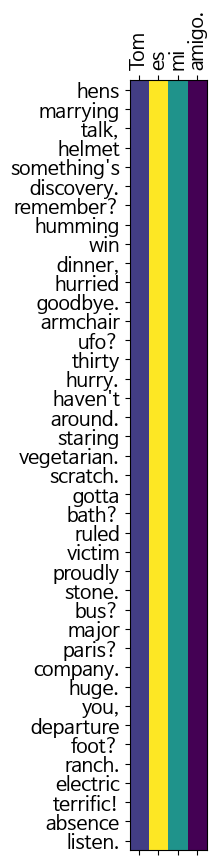

In [74]:
# 다시 가즈아!!!
translate("Tom es mi amigo.", encoder, decoder, spa_tokenizer, eng_tokenizer)

In [75]:
# 경고 메시지를 없앤 깔끔한 시각화 함수
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}
    
    # 🚨 여기에 눈금(ticks)을 먼저 설정해주는 코드를 추가했습니다!
    ax.set_xticks(range(len(sentence) + 1))
    ax.set_yticks(range(len(predicted_sentence) + 1))
    
    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.show()